# 2. The Container Stacking Rules Problem

## Tier 8 — Value-aligned & ethical framework (runnable demo)

Earlier Tiers focus on operational efficiency (minimize reshuffles). In real ports, decisions also affect:

- service fairness across customers (shipping lines)
- worker welfare (ergonomics / workload balance)
- environmental impact (extra moves → fuel / emissions)
- transparency (decisions must be explainable)

This notebook provides a small, runnable demonstration of an ethical selection layer:

- generate candidate stacking decisions
- score them on multiple dimensions
- enforce fairness constraints
- choose the best remaining solution

### Learning goals

- Translate values into measurable scores.
- Understand constraint-based filtering (fairness thresholds).
- See how a small loss in efficiency can reduce discriminatory outcomes.

### What this notebook outputs

- Candidate solutions with multi-dimensional scores
- Fairness violation analysis
- A selected ethical solution + visual comparison to a purely efficiency-driven one


In [1]:
# Environment check (no installs here)
#
# Best practice: dependencies should be preinstalled in the JupyterHub/Docker image.
# If you're running locally, install packages once in your Python environment.

from typing import List, Tuple, Dict, Optional

try:
    import itertools
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        'Missing dependency. Install: numpy, pandas, matplotlib. '
        'If you use the provided JupyterHub Docker image, these should already be installed.'
    ) from e

print('Dependencies imported successfully.')

Dependencies imported successfully.


## Concrete ethical scenario (small and runnable)

We simulate 3 shipping lines:

- Premium
- Standard
- Budget

Each container belongs to one of these customers and has a departure time.

### Key ethical idea

A purely efficiency-driven stacking policy might systematically give better positions to premium customers.

We will demonstrate how to:

- measure that imbalance
- enforce fairness constraints
- select a solution that preserves most efficiency while improving fairness


In [2]:
# Example data: containers with customer labels

containers = [
    {'id': 'P1', 'customer': 'Premium', 'd': 1},
    {'id': 'P2', 'customer': 'Premium', 'd': 4},
    {'id': 'P3', 'customer': 'Premium', 'd': 7},
    {'id': 'S1', 'customer': 'Standard', 'd': 2},
    {'id': 'S2', 'customer': 'Standard', 'd': 5},
    {'id': 'B1', 'customer': 'Budget', 'd': 3},
    {'id': 'B2', 'customer': 'Budget', 'd': 6},
]

NUM_STACKS = 3
MAX_TIERS = 3

cid_to_d = {c['id']: c['d'] for c in containers}
cid_to_customer = {c['id']: c['customer'] for c in containers}
arrival_order = [c['id'] for c in containers]

arrival_order

['P1', 'P2', 'P3', 'S1', 'S2', 'B1', 'B2']

In [3]:
# Efficiency metric: reshuffles (blocking pairs)

def count_blocking_pairs_in_stack(stack_bottom_to_top: List[str]) -> int:
    resh = 0
    for i in range(len(stack_bottom_to_top)):
        for j in range(i + 1, len(stack_bottom_to_top)):
            lower = stack_bottom_to_top[i]
            upper = stack_bottom_to_top[j]
            if cid_to_d[lower] < cid_to_d[upper]:
                resh += 1
    return resh


def total_reshuffles(stack_config: List[List[str]]) -> int:
    return sum(count_blocking_pairs_in_stack(stack) for stack in stack_config)


total_reshuffles([['P1', 'P2'], [], []])

1

## Fairness metric (service level equity)

We need a measurable notion of fairness.

A simple proxy in this stacking context:

- Each container has a retrieval cost proxy = `1 + reshuffles_needed_for_that_container`
  - `1` is the base retrieval move
  - reshuffles are extra moves caused by blocking

Then for each customer we compute the average retrieval cost across that customer's containers.

### Fairness constraint

We enforce a relative gap threshold (proxy for “maximum 20% service level variance between companies”).


## Step 1 — Define value metrics (efficiency + fairness + worker welfare + environment)

We will evaluate each candidate stacking plan on multiple dimensions.

- Efficiency: total reshuffles (blocking pairs)
- Fairness: service-level gap across customers (difference between best and worst average retrieval cost)
- Worker welfare (proxy): how unbalanced stack heights become (unbalanced bays can concentrate crane work)
- Environmental impact (proxy): extra moves implied by reshuffles (more reshuffles → more fuel/emissions)

These are simplified, but they let us demonstrate the core idea: optimize efficiency subject to ethical constraints.


In [4]:
FAIRNESS_REL_GAP_MAX = 0.20

def blocking_pairs(stack_config: List[List[str]]) -> pd.DataFrame:
    pairs = []
    for s_idx, stack in enumerate(stack_config, start=1):
        for lower_idx in range(len(stack)):
            for upper_idx in range(lower_idx + 1, len(stack)):
                lower = stack[lower_idx]
                upper = stack[upper_idx]
                if cid_to_d[lower] < cid_to_d[upper]:
                    pairs.append({
                        'stack': s_idx,
                        'lower': lower,
                        'upper': upper,
                        'lower_departure': cid_to_d[lower],
                        'upper_departure': cid_to_d[upper],
                    })
    return pd.DataFrame(pairs)


def reshuffles_needed_per_container(stack_config: List[List[str]]) -> Dict[str, int]:
    counts: Dict[str, int] = {c['id']: 0 for c in containers}
    bp = blocking_pairs(stack_config)
    if len(bp) > 0:
        for _, r in bp.iterrows():
            counts[str(r['lower'])] += 1
    return counts


def retrieval_costs_by_customer(stack_config: List[List[str]]) -> pd.DataFrame:
    resh = reshuffles_needed_per_container(stack_config)
    rows = []
    for cid in arrival_order:
        rows.append({
            'container': cid,
            'customer': cid_to_customer[cid],
            'departure_time': cid_to_d[cid],
            'reshuffles_needed': int(resh[cid]),
            'retrieval_cost': int(1 + resh[cid]),
        })
    return pd.DataFrame(rows)


def fairness_metrics(stack_config: List[List[str]]) -> Dict:
    df = retrieval_costs_by_customer(stack_config)
    avg = df.groupby('customer')['retrieval_cost'].mean().sort_values()
    min_avg = float(avg.min())
    max_avg = float(avg.max())
    abs_gap = max_avg - min_avg
    rel_gap = abs_gap / (min_avg + 1e-9)
    return {
        'avg_costs': avg,
        'min_avg': min_avg,
        'max_avg': max_avg,
        'abs_gap': float(abs_gap),
        'rel_gap': float(rel_gap),
        'fairness_ok': bool(rel_gap <= FAIRNESS_REL_GAP_MAX),
        'fairness_violation': float(max(0.0, rel_gap - FAIRNESS_REL_GAP_MAX)),
    }


def worker_welfare_proxy(stack_config: List[List[str]]) -> float:
    heights = np.array([len(s) for s in stack_config], dtype=float)
    return float(np.var(heights))


def environment_proxy_extra_moves(stack_config: List[List[str]]) -> int:
    return int(total_reshuffles(stack_config))

print('Metric helpers ready.')

Metric helpers ready.


## Step 2 — Generate candidate solutions and score them

To make the ethical framework concrete, we will:

- enumerate many candidate stacking plans (small instance → feasible to brute-force)
- compute multi-dimensional scores for each plan
- apply the fairness constraint
- select:
  - an efficiency-driven plan (best reshuffles)
  - an ethical plan (best score among those that satisfy fairness)


In [5]:
def apply_choice_sequence(choice_seq: Tuple[int, ...]) -> Optional[List[List[str]]]:
    stacks: List[List[str]] = [[] for _ in range(NUM_STACKS)]
    for cid, s_idx in zip(arrival_order, choice_seq):
        if len(stacks[s_idx]) >= MAX_TIERS:
            return None
        stacks[s_idx].append(cid)
    return stacks


W_EFF = 1.0
W_WORKER = 0.5
W_ENV = 0.75
W_FAIR_VIOL = 50.0


def candidate_scores(stack_config: List[List[str]]) -> Dict:
    eff = int(total_reshuffles(stack_config))
    fm = fairness_metrics(stack_config)
    worker = float(worker_welfare_proxy(stack_config))
    env = int(environment_proxy_extra_moves(stack_config))

    total_score = (
        W_EFF * float(eff)
        + W_WORKER * worker
        + W_ENV * float(env)
        + W_FAIR_VIOL * float(fm['fairness_violation'])
    )

    return {
        'eff_reshuffles': eff,
        'fair_rel_gap': float(fm['rel_gap']),
        'fair_ok': bool(fm['fairness_ok']),
        'worker_height_var': worker,
        'env_extra_moves': env,
        'score': float(total_score),
    }


all_sequences = list(itertools.product(range(NUM_STACKS), repeat=len(arrival_order)))
rows = []
feasible = 0

for seq in all_sequences:
    cfg = apply_choice_sequence(seq)
    if cfg is None:
        continue
    feasible += 1
    sc = candidate_scores(cfg)
    rows.append({'seq': seq, 'stack_config': cfg, **sc})

candidates_df = pd.DataFrame(rows).sort_values(
    ['eff_reshuffles', 'fair_rel_gap', 'worker_height_var', 'score'],
    ascending=True,
).reset_index(drop=True)

print('Total sequences:', len(all_sequences))
print('Feasible candidates:', feasible)

candidates_df.head(10)

Total sequences: 2187
Feasible candidates: 1050


,seq,stack_config,eff_reshuffles,fair_rel_gap,fair_ok,worker_height_var,env_extra_moves,score
0,"(0, 1, 2, 1, 2, 2, 0)","[[P1, B2], [P2, S1], [P3, S2, B1]]",1,0.333333,False,0.222222,1,8.527778
1,"(0, 2, 1, 2, 1, 1, 0)","[[P1, B2], [P3, S2, B1], [P2, S1]]",1,0.333333,False,0.222222,1,8.527778
2,"(1, 0, 2, 0, 2, 2, 1)","[[P2, S1], [P1, B2], [P3, S2, B1]]",1,0.333333,False,0.222222,1,8.527778
3,"(1, 2, 0, 2, 0, 0, 1)","[[P3, S2, B1], [P1, B2], [P2, S1]]",1,0.333333,False,0.222222,1,8.527778
4,"(2, 0, 1, 0, 1, 1, 2)","[[P2, S1], [P3, S2, B1], [P1, B2]]",1,0.333333,False,0.222222,1,8.527778
5,"(2, 1, 0, 1, 0, 0, 2)","[[P3, S2, B1], [P2, S1], [P1, B2]]",1,0.333333,False,0.222222,1,8.527778
6,"(0, 0, 1, 1, 2, 2, 1)","[[P1, P2], [P3, S1, B2], [S2, B1]]",2,0.500000,False,0.222222,2,18.611111
7,"(0, 0, 1, 2, 1, 1, 2)","[[P1, P2], [P3, S2, B1], [S1, B2]]",2,0.500000,False,0.222222,2,18.611111
8,"(0, 0, 2, 1, 2, 2, 1)","[[P1, P2], [S1, B2], [P3, S2, B1]]",2,0.500000,False,0.222222,2,18.611111
9,"(0, 0, 2, 2, 1, 1, 2)","[[P1, P2], [S2, B1], [P3, S1, B2]]",2,0.500000,False,0.222222,2,18.611111


## Step 3 — Select an efficiency-driven plan vs an ethical plan

We compare two decisions:

- Efficiency-driven: choose the plan with the lowest reshuffles
- Ethical: choose the best plan among those that satisfy the fairness constraint (`fair_ok == True`)

This mirrors the narrative: accept a small efficiency loss (if needed) to prevent discriminatory service outcomes.


In [6]:
min_resh = int(candidates_df['eff_reshuffles'].min())

best_eff_row = (
    candidates_df[candidates_df['eff_reshuffles'] == min_resh]
    .sort_values(['score', 'fair_rel_gap', 'worker_height_var'], ascending=True)
    .iloc[0]
)
best_eff_cfg = best_eff_row['stack_config']

fair_df = candidates_df[candidates_df['fair_ok'] == True].copy()

if len(fair_df) == 0:
    best_eth_row = (
        candidates_df.sort_values(['fair_rel_gap', 'eff_reshuffles', 'score'], ascending=True)
        .iloc[0]
    )
    fairness_note = 'No candidate satisfied fairness; selected the least-unfair plan.'
else:
    best_eth_row = fair_df.sort_values(['score', 'eff_reshuffles'], ascending=True).iloc[0]
    fairness_note = 'Selected among candidates that satisfy fairness.'

best_eth_cfg = best_eth_row['stack_config']

print('Efficiency-driven plan:')
print('- reshuffles:', int(best_eff_row['eff_reshuffles']))
print('- fairness rel gap:', float(best_eff_row['fair_rel_gap']))
print('- fair_ok:', bool(best_eff_row['fair_ok']))
print('- score:', float(best_eff_row['score']))

print('\nEthical plan:')
print('- note:', fairness_note)
print('- reshuffles:', int(best_eth_row['eff_reshuffles']))
print('- fairness rel gap:', float(best_eth_row['fair_rel_gap']))
print('- fair_ok:', bool(best_eth_row['fair_ok']))
print('- score:', float(best_eth_row['score']))

top_snapshot = (
    fair_df.sort_values(['score', 'eff_reshuffles'], ascending=True).head(10)
    if len(fair_df) > 0
    else candidates_df.sort_values(['fair_rel_gap', 'eff_reshuffles', 'score'], ascending=True).head(10)
)

top_snapshot[['eff_reshuffles', 'fair_rel_gap', 'fair_ok', 'worker_height_var', 'env_extra_moves', 'score', 'seq']]

Efficiency-driven plan:
- reshuffles: 1
- fairness rel gap: 0.3333333329999999
- fair_ok: False
- score: 8.527777761111105

Ethical plan:
- note: Selected among candidates that satisfy fairness.
- reshuffles: 3
- fairness rel gap: 0.12499999990625006
- fair_ok: True
- score: 5.361111111111111


,eff_reshuffles,fair_rel_gap,fair_ok,worker_height_var,env_extra_moves,score,seq
126,3,0.125,True,0.222222,3,5.361111,"(0, 0, 1, 1, 1, 2, 2)"
127,3,0.125,True,0.222222,3,5.361111,"(0, 0, 1, 1, 2, 2, 2)"
128,3,0.125,True,0.222222,3,5.361111,"(0, 0, 1, 2, 2, 1, 1)"
129,3,0.125,True,0.222222,3,5.361111,"(0, 0, 2, 1, 1, 2, 2)"
130,3,0.125,True,0.222222,3,5.361111,"(0, 0, 2, 2, 1, 1, 1)"
131,3,0.125,True,0.222222,3,5.361111,"(0, 0, 2, 2, 2, 1, 1)"
132,3,0.125,True,0.222222,3,5.361111,"(0, 1, 0, 1, 2, 2, 2)"
133,3,0.125,True,0.222222,3,5.361111,"(0, 2, 0, 2, 1, 1, 1)"
134,3,0.125,True,0.222222,3,5.361111,"(1, 0, 1, 0, 2, 2, 2)"
135,3,0.125,True,0.222222,3,5.361111,"(1, 1, 0, 0, 0, 2, 2)"


## Step 4 — Explainability: show stakeholder impacts

To keep decisions transparent, we print:

- per-container retrieval cost proxy
- per-customer average retrieval cost
- fairness gap values

This is the kind of audit output an accountability layer would retain.


In [7]:
def report_plan(name: str, cfg: List[List[str]]):
    fm = fairness_metrics(cfg)

    print('=' * 80)
    print(name)
    print('Stack config:', cfg)
    print('Reshuffles:', int(total_reshuffles(cfg)))
    print('Fairness rel gap:', float(fm['rel_gap']))
    print('Fairness ok:', bool(fm['fairness_ok']))

    avg_df = fm['avg_costs'].to_frame('avg_retrieval_cost')
    per_df = retrieval_costs_by_customer(cfg).sort_values(['customer', 'departure_time'])

    return avg_df, per_df


avg_eff, per_eff = report_plan('Efficiency-driven plan', best_eff_cfg)
avg_eth, per_eth = report_plan('Ethical plan', best_eth_cfg)

avg_eff, avg_eth

Efficiency-driven plan
Stack config: [['P1', 'B2'], ['P2', 'S1'], ['P3', 'S2', 'B1']]
Reshuffles: 1
Fairness rel gap: 0.3333333329999999
Fairness ok: False
Ethical plan
Stack config: [['P1', 'P2'], ['P3', 'S1', 'S2'], ['B1', 'B2']]
Reshuffles: 3
Fairness rel gap: 0.12499999990625006
Fairness ok: True


(          avg_retrieval_cost
 customer                    
 Budget              1.000000
 Standard            1.000000
 Premium             1.333333,
           avg_retrieval_cost
 customer                    
 Premium             1.333333
 Budget              1.500000
 Standard            1.500000)

## Step 5 — Visual comparison

We visualize both plans using the same diagram style:

- stacks (bottom → top)
- container label includes customer + departure time
- blocking arrows (upper blocks lower)

Then we compare customer-level service outcomes side by side.


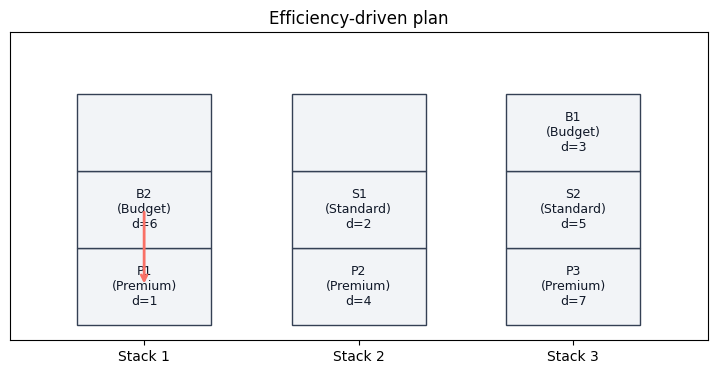

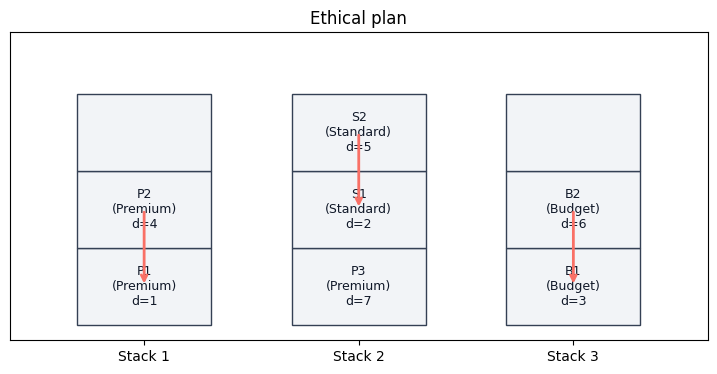

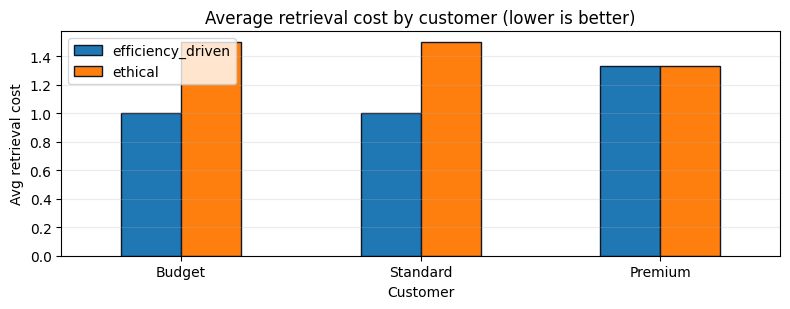

,efficiency_driven,ethical
customer,,
Budget,1.000000,1.500000
Standard,1.000000,1.500000
Premium,1.333333,1.333333


In [8]:
def plot_stack_with_blocking(cfg: List[List[str]], title: str):
    bp = blocking_pairs(cfg)

    fig, ax = plt.subplots(figsize=(9, 4))

    stack_width = 1.0
    cell_height = 1.0
    x_gap = 0.6

    stack_x = {s_idx: (s_idx - 1) * (stack_width + x_gap) for s_idx in range(1, NUM_STACKS + 1)}

    for s_idx in range(1, NUM_STACKS + 1):
        x0 = stack_x[s_idx]
        for tier in range(MAX_TIERS):
            rect = plt.Rectangle(
                (x0, tier * cell_height),
                stack_width,
                cell_height,
                facecolor='#F2F4F7',
                edgecolor='#344054',
            )
            ax.add_patch(rect)

    for s_idx, stack in enumerate(cfg, start=1):
        x0 = stack_x[s_idx]
        for tier, cid in enumerate(stack):
            cust = cid_to_customer[cid]
            d = cid_to_d[cid]
            ax.text(
                x0 + stack_width / 2,
                tier * cell_height + cell_height / 2,
                f'{cid}\n({cust})\nd={d}',
                ha='center',
                va='center',
                fontsize=9,
                color='#101828',
            )

    if len(bp) > 0:
        for _, row in bp.iterrows():
            s_idx = int(row['stack'])
            lower = str(row['lower'])
            upper = str(row['upper'])

            stack = cfg[s_idx - 1]
            lower_tier = stack.index(lower)
            upper_tier = stack.index(upper)

            x = stack_x[s_idx] + stack_width / 2
            y_lower = lower_tier * cell_height + cell_height / 2
            y_upper = upper_tier * cell_height + cell_height / 2

            ax.annotate(
                '',
                xy=(x, y_lower),
                xytext=(x, y_upper),
                arrowprops=dict(arrowstyle='->', lw=2, color='#F97066'),
            )

    ax.set_title(title)
    ax.set_xticks([stack_x[s] + stack_width / 2 for s in range(1, NUM_STACKS + 1)])
    ax.set_xticklabels([f'Stack {s}' for s in range(1, NUM_STACKS + 1)])
    ax.set_yticks([])
    ax.set_xlim(-0.5, stack_x[NUM_STACKS] + stack_width + 0.5)
    ax.set_ylim(-0.2, MAX_TIERS * cell_height + 0.8)

    plt.show()


plot_stack_with_blocking(best_eff_cfg, 'Efficiency-driven plan')
plot_stack_with_blocking(best_eth_cfg, 'Ethical plan')

avg_compare = pd.concat(
    [
        avg_eff.rename(columns={'avg_retrieval_cost': 'efficiency_driven'}),
        avg_eth.rename(columns={'avg_retrieval_cost': 'ethical'}),
    ],
    axis=1,
)

ax = avg_compare.plot(kind='bar', figsize=(8, 3.2), rot=0, edgecolor='#101828')
ax.set_title('Average retrieval cost by customer (lower is better)')
ax.set_xlabel('Customer')
ax.set_ylabel('Avg retrieval cost')
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

avg_compare

## Additional analysis: make the trade-offs explicit (score breakdown + alternative ethical selection)

When we say a plan is more "ethical", we should be able to explain **which terms** changed:

- efficiency (`eff_reshuffles`)
- fairness (`fairness_violation` / `fair_rel_gap`)
- worker proxy (height variance)
- environment proxy (extra moves)

Below we:

- show a **score breakdown table** for the chosen plans
- show an alternative ethical selection rule: **minimize reshuffles among fair plans** (a constraint-first view)

This makes the trade-off logic transparent and easier to teach.

In [9]:
# Score breakdown for the chosen plans + an alternative ethical selection rule.


def score_breakdown(stack_config: List[List[str]]) -> Dict[str, float]:
    eff = float(total_reshuffles(stack_config))
    fm = fairness_metrics(stack_config)
    worker = float(worker_welfare_proxy(stack_config))
    env = float(environment_proxy_extra_moves(stack_config))

    fair_violation = float(fm["fairness_violation"])

    return {
        "eff_reshuffles": eff,
        "fair_rel_gap": float(fm["rel_gap"]),
        "fairness_violation": fair_violation,
        "worker_height_var": worker,
        "env_extra_moves": env,
        "term_eff": W_EFF * eff,
        "term_worker": W_WORKER * worker,
        "term_env": W_ENV * env,
        "term_fair_violation": W_FAIR_VIOL * fair_violation,
        "score": (W_EFF * eff) + (W_WORKER * worker) + (W_ENV * env) + (W_FAIR_VIOL * fair_violation),
    }


bd_eff = score_breakdown(best_eff_cfg)
bd_eth = score_breakdown(best_eth_cfg)

breakdown_df = pd.DataFrame([bd_eff, bd_eth], index=["efficiency_driven", "ethical"]).round(4)
breakdown_df


# Alternative ethical selection: constraint-first
# "Among fair plans, minimize reshuffles; break ties by score"
if len(fair_df) > 0:
    alt_row = fair_df.sort_values(["eff_reshuffles", "score"], ascending=True).iloc[0]
    alt_cfg = alt_row["stack_config"]

    print("Alternative ethical selection (min reshuffles among fair plans):")
    print("- reshuffles:", int(alt_row["eff_reshuffles"]))
    print("- fairness rel gap:", float(alt_row["fair_rel_gap"]))
    print("- score:", float(alt_row["score"]))

    alt_bd = score_breakdown(alt_cfg)
    pd.DataFrame([alt_bd], index=["ethical_alt_min_reshuffles"]).round(4)
else:
    print("No fairness-satisfying plan exists under the current FAIRNESS_REL_GAP_MAX.")

Alternative ethical selection (min reshuffles among fair plans):
- reshuffles: 3
- fairness rel gap: 0.12499999990625006
- score: 5.361111111111111


## Why this Tier exists vs earlier Tiers (comparison)

### Why Tier 8 exists

Earlier Tiers treat the objective as purely operational (minimize reshuffles). In practice, automated decisions also create stakeholder impacts.

Tier 8 exists to demonstrate a pattern you can apply to any optimizer/policy:

- generate solutions using Tier 1–4 techniques
- evaluate them against value constraints (fairness, safety, environment)
- select a solution that is efficient and acceptable

### Advantages

- Makes trade-offs explicit and measurable
- Creates an auditable decision trail
- Can be layered on top of heuristics, GA, or RL

### Disadvantages

- Requires agreement on metrics and thresholds
- Can reduce pure efficiency
- Needs careful governance to avoid gaming the metrics

### When to use Tier 8

- Multi-customer terminals where service equity is regulated or contractually required
- When automation must be explainable and contestable
- When sustainability and worker-safety KPIs are first-class constraints
